# Dubai Real Estate Market Analysis (2020–2026)
### Exploratory Data Analysis, Price Forecasting, Market Analysis

data source : https://www.kaggle.com/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/data

A comprehensive dataset of the Dubai real estate market covering three segments — secondary sales, off-plan (new construction), and rentals — across 84 communities and 52 zones. Spans January 2020 to April 2026, capturing the most consequential market events of the period: the COVID-era dip, the Expo 2020 anticipation rally, the post-2022 capital influx (notably from Russia and the CIS), the October 2022 Golden Visa expansion, and the post-rally cooling of 2024–2025.

The dataset combines real geographic anchors (community coordinates, Dubai Metro stations, CBUAE base rate timeline, DLD/Property Finder–anchored base prices per zone) with a hedonic pricing model that produces realistic listing-level data. Coordinates and metro stations are real; listing-level apartment characteristics are generated from the hedonic model.

All prices are in USD for international comparability. Area is provided in both sqft (Dubai standard) and m² (international standard).

### what do i want to do here?

I want to answer 1 question: What factors influence property prices in Dubai, and what are the future prospects?

### 1. Setup & Data Overview

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import warnings
# warnings.filterwarnings("ignore")

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sergionefedov/dubai-real-estate-sales-and-rentals-20202026")

print("Path to dataset files:", path)

import os

data_name = os.listdir(path)
data_name

Path to dataset files: C:\Users\FATHIR\.cache\kagglehub\datasets\sergionefedov\dubai-real-estate-sales-and-rentals-20202026\versions\2


['area_prices_monthly.csv',
 'metro_stations.csv',
 'off_plan.csv',
 'rentals.csv',
 'secondary_sales.csv']

In [11]:
area_prices = pd.read_csv(os.path.join(path, data_name[0]))
metro_prices = pd.read_csv(os.path.join(path, data_name[1]))
offplan = pd.read_csv(os.path.join(path, data_name[2]), parse_dates=['date_listed'])
rentals = pd.read_csv(os.path.join(path, data_name[3]), parse_dates=['date_listed'])
secondary = pd.read_csv(os.path.join(path, data_name[4]), parse_dates=['date_listed'])

In [12]:
from IPython.display import display

print("=== AREA PRICES ===")
display(area_prices.head(), area_prices.shape)

print("=== METRO PRICES ===")
display(metro_prices.head(), metro_prices.shape)

print("=== OFFPLAN ===")
display(offplan.head(), offplan.shape)

print("=== RENTALS ===")
display(rentals.head())

print("=== SECONDARY SALES ===")
display(secondary.head(), secondary.shape)

=== AREA PRICES ===


,year_month,community,zone,is_freehold,secondary_price_per_sqft_usd,secondary_price_per_m2_usd,offplan_price_per_sqft_usd,rental_price_per_sqft_annual_usd,n_listings_secondary,n_listings_offplan,n_listings_rental,cbuae_base_rate_pct,avg_mortgage_rate_pct
0,2020-01,Palm Jumeirah,Palm Jumeirah,True,662,7126,752.0,43,26,72,111,1.5,3.0
1,2020-02,Palm Jumeirah,Palm Jumeirah,True,666,7167,728.0,43,64,78,45,1.5,3.0
2,2020-03,Palm Jumeirah,Palm Jumeirah,True,703,7564,762.0,46,144,71,99,1.5,3.0
3,2020-04,Palm Jumeirah,Palm Jumeirah,True,651,7002,727.0,42,146,69,14,0.4,1.9
4,2020-05,Palm Jumeirah,Palm Jumeirah,True,637,6852,676.0,41,147,28,83,0.4,1.9


(6384, 13)

=== METRO PRICES ===


,station_name,line,lat,lon,year_opened,to_burj_khalifa_km
0,UAE Exchange,Red,24.9756,55.0700,2011,32.11
1,Energy,Red,24.9844,55.0866,2011,30.29
2,Ibn Battuta,Red,25.0445,55.1180,2011,23.16
3,Jebel Ali,Red,25.0050,55.1335,2011,25.65
4,Danube,Red,25.0185,55.1230,2011,25.04


...

=== RENTALS ===


,id,date_listed,community,zone,lat,lon,property_category,property_type,bedrooms,area_sqft,...,parking_spaces,metro_station,metro_line,metro_distance_min,to_burj_khalifa_km,contract_type,n_cheques,annual_rent_usd,rent_per_sqft_usd,rent_per_m2_usd
0,R000001,2024-12-20,Town Square,Nshama,25.02906,55.25610,apartment,1BR,1,748,...,1,Centrepoint,Red,373,18.79,yearly,6,13700,18,196
1,R000002,2021-07-06,Expo City,Dubai South,24.96152,55.15759,apartment,1BR,1,1011,...,2,Expo 2020,Red,7,28.73,yearly,6,12700,12,135
2,R000003,2023-05-10,Palm Jumeirah,Palm Jumeirah,25.10836,55.13304,apartment,1BR,1,825,...,2,Mashreq Bank,Red,44,17.32,yearly,1,59900,72,782
3,R000004,2021-12-30,Deira,Deira,25.28720,55.30205,apartment,1BR,1,755,...,1,Al Jafiliya,Red,62,10.39,yearly,1,9300,12,133
4,R000005,2023-12-08,The Views,The Greens,25.08438,55.18399,apartment,1BR,1,746,...,1,Dubai Internet City,Red,5,15.50,short_term,12,31300,41,451


=== SECONDARY SALES ===


,id,date_listed,community,zone,is_freehold,lat,lon,property_category,property_type,bedrooms,...,chiller_included,metro_station,metro_line,metro_distance_min,metro_distance_type,to_burj_khalifa_km,price_usd,price_per_sqft_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,DIFC,DIFC,True,25.21053,55.29453,apartment,4BR_penthouse,4,...,True,Financial Centre,Red,6,walk,2.51,4806100,1314,14141,6.15
1,S000002,2023-07-05,DIFC,DIFC,True,25.21330,55.28617,apartment,3BR,3,...,True,Emirates Towers,Red,13,walk,2.15,2287400,1283,13813,6.90
2,S000003,2022-01-22,Karama,Bur Dubai,False,25.24835,55.29501,apartment,1BR,1,...,False,BurJuman (G),Green,14,walk,6.05,167100,203,2184,1.90
3,S000004,2021-10-28,The Valley,Dubai-Al Ain Road,True,24.95989,55.48870,villa,5BR_villa,5,...,False,Discovery Gardens,Red,151,drive,34.09,832000,154,1658,1.90
4,S000005,2025-05-30,Sobha Hartland,MBR City,True,25.17393,55.28697,apartment,3BR,3,...,True,Financial Centre,Red,23,drive,2.88,1323400,660,7104,6.15


(50000, 29)

In [13]:
def segment_stats(df, price_col, name):
    print(f'\n=== {name} ===')
    print(f'  Date range : {df["date_listed"].min().date()} -> {df["date_listed"].max().date()}')
    print(f'  Communities: {df["community"].nunique()}')
    print(f'  Median {price_col}: {df[price_col].median():>15,.0f} USD')
    print(f'  Mean   {price_col}: {df[price_col].mean():>15,.0f} USD')

segment_stats(secondary, 'price_usd', 'Secondary Sales')
segment_stats(offplan,   'price_usd', 'Off-Plan')
segment_stats(rentals,   'annual_rent_usd', 'Rentals')


=== Secondary Sales ===
  Date range : 2020-01-01 -> 2026-04-29
  Communities: 84
  Median price_usd:         593,700 USD
  Mean   price_usd:       1,014,038 USD

=== Off-Plan ===
  Date range : 2021-01-01 -> 2026-04-29
  Communities: 71
  Median price_usd:       1,018,100 USD
  Mean   price_usd:       1,698,503 USD

=== Rentals ===
  Date range : 2021-01-01 -> 2026-04-29
  Communities: 84
  Median annual_rent_usd:          47,050 USD
  Mean   annual_rent_usd:          83,687 USD


## Chapter : 1. Dubai Real Estate Market Condition

In [18]:
zone_stats = secondary.groupby('zone').agg(
    mean_price_per_sqft = ('price_per_sqft_usd', 'mean'),
    n_listings = ('id', 'count')
).sort_values('mean_price_per_sqft', ascending=False).reset_index()

zone_stats.head(15)

,zone,mean_price_per_sqft,n_listings
0,Jumeirah Bay,2276.821849,595
1,DIFC,1066.754653,591
2,Jumeirah,935.467819,4801
3,Emirates Hills,910.772652,607
4,Downtown,898.110016,609
5,Palm Jumeirah,885.709507,568
6,World Islands,859.608997,578
7,Al Wasl,743.522689,595
8,Dubai Marina,629.029961,2303
9,Business Bay,585.380952,546


### 1.1 where is the zone with the most expensive prices?

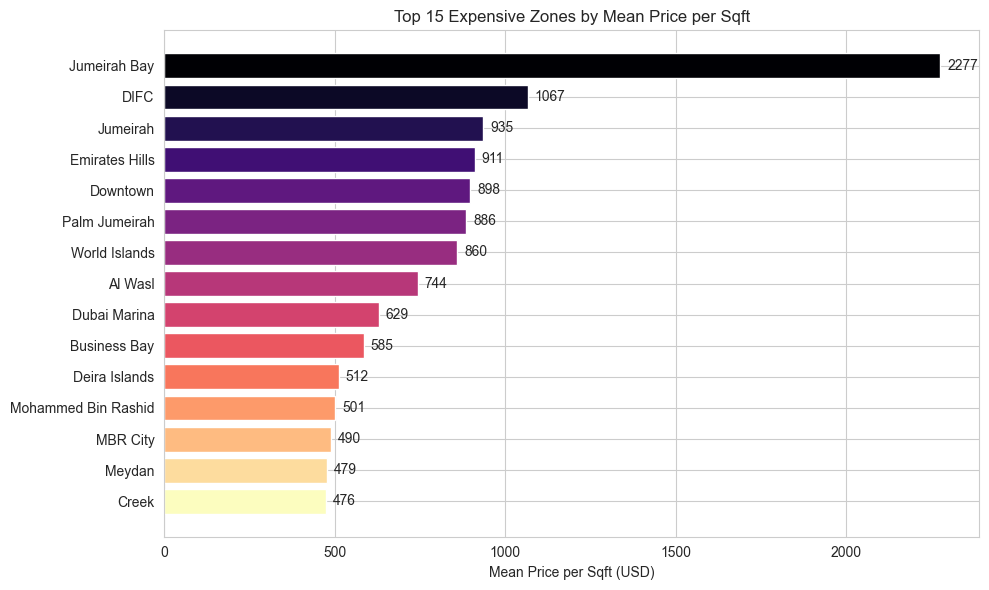

<Figure size 640x480 with 0 Axes>

In [27]:
colors = plt.cm.magma(np.linspace(0, 1, len(zone_stats.head(15))))

top15 = zone_stats.head(15)

plt.figure(figsize=(10, 6))
barh =plt.barh(
    y=top15['zone'],                 
    width=top15['mean_price_per_sqft'],
    color=colors
)

plt.title('Top 15 Expensive Zones by Mean Price per Sqft')
plt.xlabel('Mean Price per Sqft (USD)')
plt.bar_label(barh, fmt='%.0f', padding=5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

os.makedirs('plots', exist_ok=True)
file_path = os.path.join('plots', 'top15_zones_price_per_sqft.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')